In [1]:
import sys
print(sys.executable)

d:\Anaconda\envs\ulcers\python.exe


Importar librerias

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
csv_path = r"D:\Documentos\UPC\GUTTMANN\demo2\data\metadata\Imatges UPP LPP a 20251119_photos_ulcers(Imatges UPP LPP a 20251119).csv"

df = pd.read_csv(csv_path, sep=";", encoding="latin1") #diferente a UTF-8 porque hay caracteres con acento o ç. 

print("Número de filas:", len(df))

df.columns

df.head()

Número de filas: 2248


,Id,Data creacio,Interna externa,C loc,Localitzacio,C estat,Estat,C motiu fi,Motiu fi,Data fi,Data seguiment,Grau,Exudat,Teixit,Tipus imatge,Arxiu imatge,Data imatge
0,786,2015-08-01 00:00:00,E,2,occipital,2,finalitzada,3.0,Resolució,2015-10-13 00:00:00,2015-09-02 10:16:06,3,1,3,UPP,2.jpg,2015-09-02 16:06:12
1,786,2015-08-01 00:00:00,E,2,occipital,2,finalitzada,3.0,Resolució,2015-10-13 00:00:00,2015-09-02 10:16:06,3,1,3,UPP,3.jpg,2015-09-02 16:06:25
2,786,2015-08-01 00:00:00,E,2,occipital,2,finalitzada,3.0,Resolució,2015-10-13 00:00:00,2015-09-02 10:16:06,3,1,3,UPP,4.jpg,2015-09-02 16:06:35
3,816,2015-10-13 00:00:00,E,11,sacre,3,no resolta a l'alta,1.0,Alta,2016-05-27 00:00:00,2015-10-15 16:06:31,3,2,3,UPP,5.jpg,2015-10-15 07:47:37
4,844,2015-01-23 00:00:00,E,24,taló dret,2,finalitzada,1.0,Alta,2016-03-31 00:00:00,2016-01-23 10:25:31,2,0,4,UPP,6.jpg,2016-01-23 10:04:14


In [13]:
df["Tipus imatge"].value_counts()

Tipus imatge
UPP    2068
FER     180
Name: count, dtype: int64

In [14]:
df["Grau"].value_counts().sort_index()

Grau
0    307
1    103
2    687
3    585
4    505
5     61
Name: count, dtype: int64

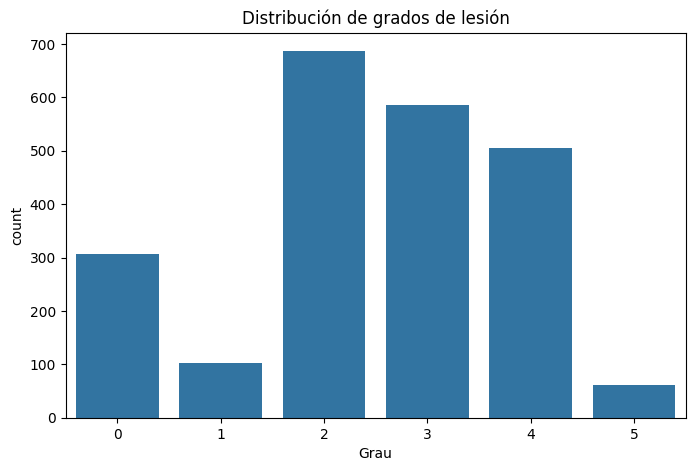

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Grau")
plt.title("Distribución de grados de lesión")
plt.show()
#Vemos desbalance de clases. Muy pocas samples de 0 y 5. Deberemos arreglarlo con class weights, focal loss y/o balanced sampler

Dataset cleaning

In [17]:
#Just UPP
df_upp = df[df["Tipus imatge"] == "UPP"]

print("UPP images:", len(df_upp))

UPP images: 2068


In [19]:
#No stage 0
df_upp = df_upp[df_upp["Grau"] != 0]

print("After removing Grau 0:", len(df_upp))

After removing Grau 0: 1930


In [21]:
#Final distribution
df_upp["Grau"].value_counts().sort_index()

Grau
1    101
2    682
3    582
4    505
5     60
Name: count, dtype: int64

In [ ]:
images_folder = r"D:\Documentos\UPC\GUTTMANN\demo2\data\raw\photos_ulcers"

df_upp["image_path"] = df_upp["Arxiu imatge"].apply(lambda x: os.path.join(images_folder, str(x)))

df_upp["exists"] = df_upp["image_path"].apply(os.path.exists)

print(df_upp["exists"].value_counts())

#All remaining records have a valid image file

exists
True    1930
Name: count, dtype: int64


BUILD CLEAN DATASET

In [23]:
# Rename columns to English

df_clean = df_upp.rename(columns={
    "Id": "patient_id",
    "Grau": "stage",
    "Exudat": "exudate_level",
    "Teixit": "tissue_type",
    "Tipus imatge": "image_type",
    "Arxiu imatge": "image_filename",
    "Data imatge": "image_date"
})

In [24]:
df_clean = df_clean[[
    "patient_id",
    "stage",
    "exudate_level",
    "tissue_type",
    "image_filename",
    "image_date",
    "image_path"
]]

df_clean.head()

,patient_id,stage,exudate_level,tissue_type,image_filename,image_date,image_path
0,786,3,1,3,2.jpg,2015-09-02 16:06:12,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...
1,786,3,1,3,3.jpg,2015-09-02 16:06:25,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...
2,786,3,1,3,4.jpg,2015-09-02 16:06:35,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...
3,816,3,2,3,5.jpg,2015-10-15 07:47:37,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...
4,844,2,0,4,6.jpg,2016-01-23 10:04:14,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...


In [25]:
df_clean["stage"].value_counts().sort_index()

stage
1    101
2    682
3    582
4    505
5     60
Name: count, dtype: int64

In [26]:
output_path = r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\dataset_upp_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


NO DATA LEAKAGE - PATIENTS

In [27]:
# Number of unique patients

n_patients = df_clean["patient_id"].nunique()

print("Number of unique patients:", n_patients)

Number of unique patients: 880


In [28]:
images_per_patient = df_clean.groupby("patient_id").size()

print("Average images per patient:", images_per_patient.mean())
print("Max images per patient:", images_per_patient.max())

Average images per patient: 2.1931818181818183
Max images per patient: 14


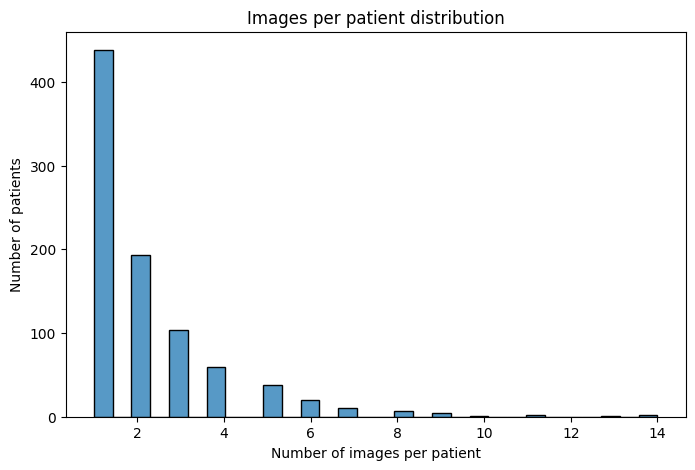

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(images_per_patient, bins=30)

plt.title("Images per patient distribution")
plt.xlabel("Number of images per patient")
plt.ylabel("Number of patients")

plt.show()

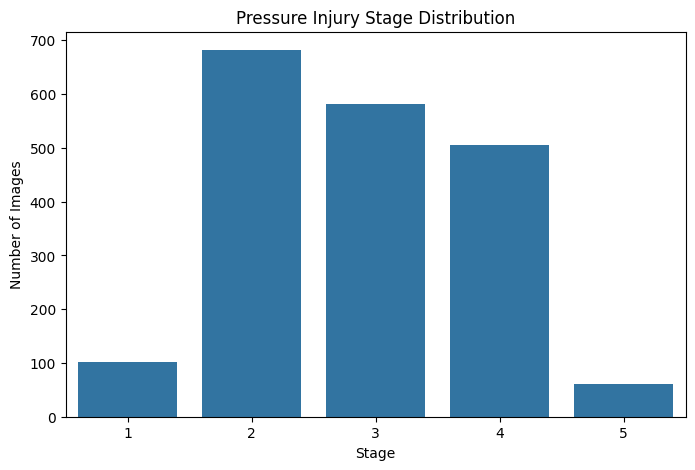

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x="stage")

plt.title("Pressure Injury Stage Distribution")
plt.xlabel("Stage")
plt.ylabel("Number of Images")

plt.show()

PATIENT-LEVEL SPLIT

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
patients = df_clean["patient_id"].unique()

print("Total patients:", len(patients))

Total patients: 880


In [33]:
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

In [ ]:
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)
# Hemos dividido train 70%, validation 15%, test 15%

In [36]:
train_df = df_clean[df_clean["patient_id"].isin(train_patients)]
val_df = df_clean[df_clean["patient_id"].isin(val_patients)]
test_df = df_clean[df_clean["patient_id"].isin(test_patients)]

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 1308
Validation images: 303
Test images: 319


In [37]:
print("\nTrain stage distribution:")
print(train_df["stage"].value_counts().sort_index())

print("\nValidation stage distribution:")
print(val_df["stage"].value_counts().sort_index())

print("\nTest stage distribution:")
print(test_df["stage"].value_counts().sort_index())


Train stage distribution:
stage
1     61
2    466
3    398
4    339
5     44
Name: count, dtype: int64

Validation stage distribution:
stage
1    24
2    94
3    89
4    90
5     6
Name: count, dtype: int64

Test stage distribution:
stage
1     16
2    122
3     95
4     76
5     10
Name: count, dtype: int64


In [38]:
train_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\train_dataset.csv", index=False)
val_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\val_dataset.csv", index=False)
test_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\test_dataset.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


EXPLORATORY VISUAL ANALYSIS

In [ ]:
#SEE RANDOM IMAGES
from PIL import Image
import random

def show_random_images(df, n=9):
    
    sample = df.sample(n)
    
    plt.figure(figsize=(10,10))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        
        img = Image.open(row["image_path"])
        
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(f"Stage {row['stage']}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

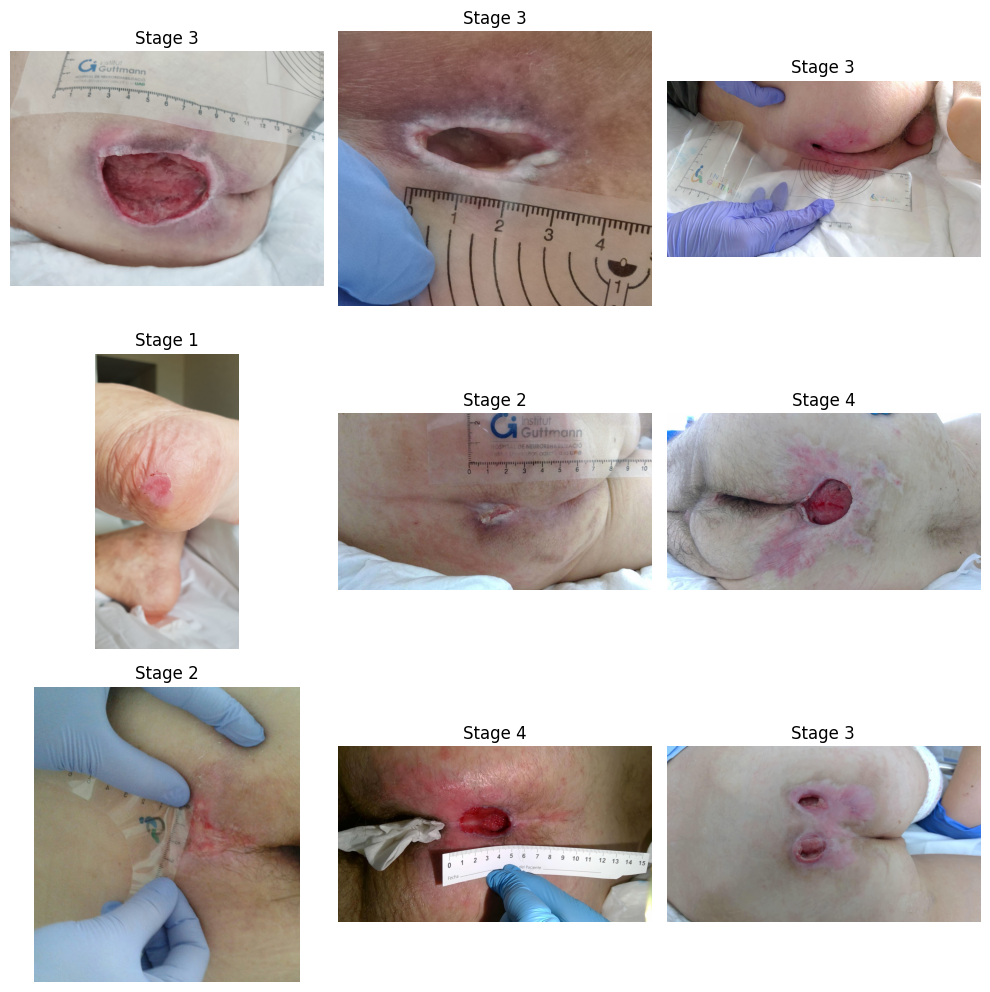

In [40]:
show_random_images(train_df, n=9)

In [41]:
#SEE IMAGES BY STAGES
def show_stage_examples(df, stage, n=6):
    
    subset = df[df["stage"] == stage].sample(n)
    
    plt.figure(figsize=(12,4))
    
    for i, (_, row) in enumerate(subset.iterrows()):
        
        img = Image.open(row["image_path"])
        
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(f"Stage {stage}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

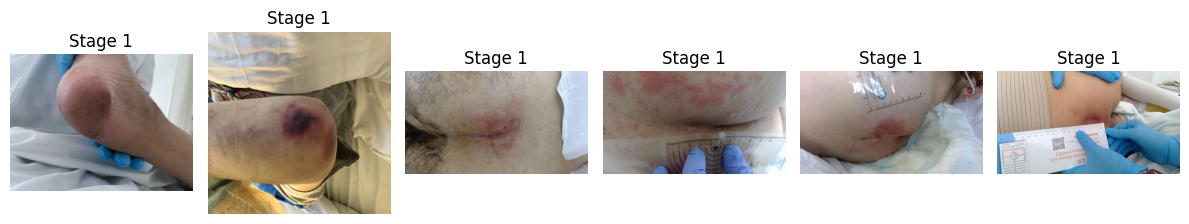

In [42]:
show_stage_examples(train_df, stage=1)

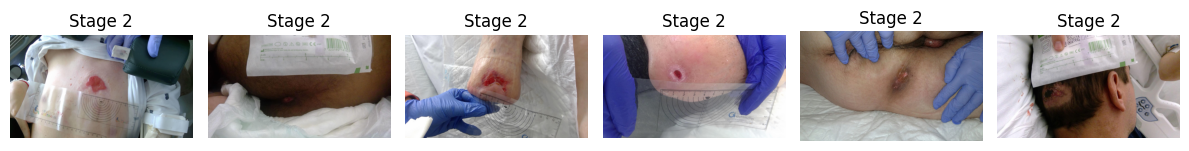

In [43]:
show_stage_examples(train_df, stage=2)

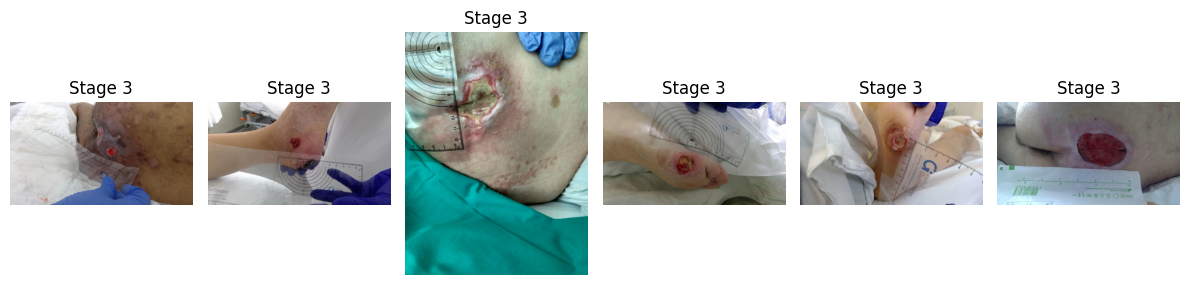

In [44]:
show_stage_examples(train_df, stage=3)

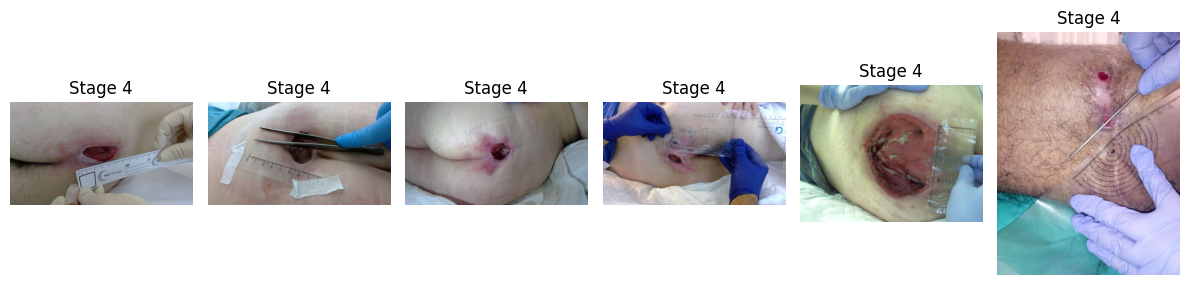

In [45]:
show_stage_examples(train_df, stage=4)

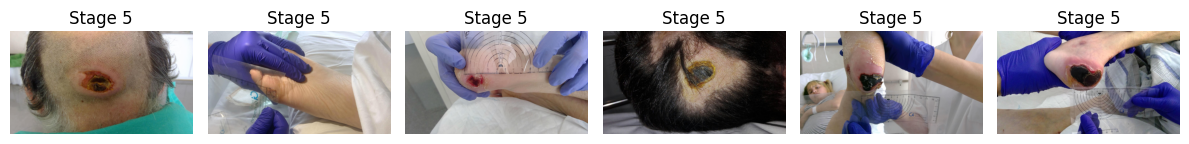

In [46]:
show_stage_examples(train_df, stage=5)

IMAGE RESOLUTION ANALYSIS

In [47]:
from PIL import Image

widths = []
heights = []

for path in df_clean["image_path"]:
    
    img = Image.open(path)
    w, h = img.size
    
    widths.append(w)
    heights.append(h)

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Min height:", min(heights))
print("Max height:", max(heights))

Min width: 576
Max width: 5712
Min height: 439
Max height: 4284


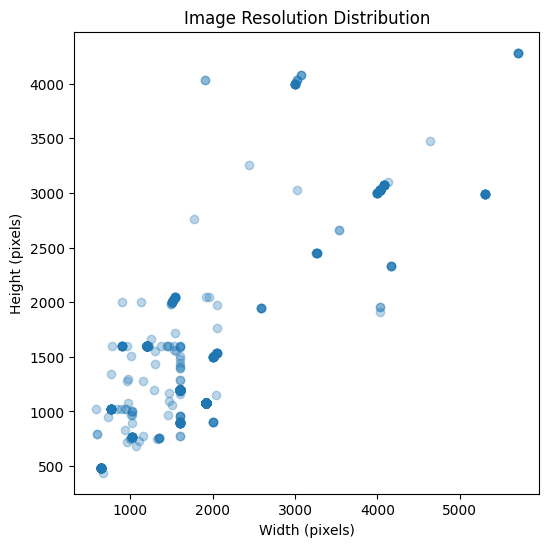

In [48]:
plt.figure(figsize=(6,6))

plt.scatter(widths, heights, alpha=0.3)

plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Resolution Distribution")

plt.show()

DUPLICATE IMAGE DETECTION

In [49]:
df_clean["image_filename"].duplicated().sum()

np.int64(12)

In [50]:
import hashlib

def get_image_hash(path):
    
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = df_clean["image_path"].apply(get_image_hash)

duplicate_hashes = hashes.duplicated().sum()

print("Duplicate images:", duplicate_hashes)

Duplicate images: 13


In [51]:
# Remove duplicate images using hash

df_clean["image_hash"] = hashes

df_clean = df_clean.drop_duplicates(subset="image_hash")

print("Dataset size after removing duplicates:", len(df_clean))

Dataset size after removing duplicates: 1917


NEW PATIENT-LEVEL SPLIT

In [52]:
print("Final dataset size:", len(df_clean))

Final dataset size: 1917


In [53]:
patients = df_clean["patient_id"].unique()

print("Total patients:", len(patients))

Total patients: 880


In [54]:
from sklearn.model_selection import train_test_split

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

In [55]:
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

In [56]:
train_df = df_clean[df_clean["patient_id"].isin(train_patients)]
val_df = df_clean[df_clean["patient_id"].isin(val_patients)]
test_df = df_clean[df_clean["patient_id"].isin(test_patients)]

In [57]:
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 1301
Validation images: 300
Test images: 316


In [58]:
print("\nTrain stage distribution:")
print(train_df["stage"].value_counts().sort_index())

print("\nValidation stage distribution:")
print(val_df["stage"].value_counts().sort_index())

print("\nTest stage distribution:")
print(test_df["stage"].value_counts().sort_index())


Train stage distribution:
stage
1     61
2    464
3    395
4    338
5     43
Name: count, dtype: int64

Validation stage distribution:
stage
1    24
2    94
3    87
4    90
5     5
Name: count, dtype: int64

Test stage distribution:
stage
1     15
2    120
3     95
4     76
5     10
Name: count, dtype: int64


In [59]:
train_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\train_dataset.csv", index=False)
val_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\val_dataset.csv", index=False)
test_df.to_csv(r"D:\Documentos\UPC\GUTTMANN\demo2\data\processed\test_dataset.csv", index=False)

print("New datasets saved successfully.")

New datasets saved successfully.
